In [ ]:
import os
import sys
import math
import json
import shutil
import random
import subprocess
import importlib
from pathlib import Path
from datetime import datetime, timezone, timedelta

def run_cmd(cmd, check=True):
    print(f"\n$ {' '.join(cmd)}")
    result = subprocess.run(cmd, text=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
    print(result.stdout[-4000:])
    if check and result.returncode != 0:
        raise RuntimeError(f"Command failed with exit code {result.returncode}: {' '.join(cmd)}")
    return result

print("Python:", sys.version)

if sys.version_info < (3, 11):
    raise RuntimeError(
        "PyneCore requires Python 3.11+. In Colab, use a current runtime or restart with Python 3.11+."
    )

run_cmd([
    sys.executable, "-m", "pip", "install", "-q",
    "pynesys-pynecore[cli]",
    "pandas",
    "numpy",
    "matplotlib",
    "rich",
    "tzdata"
])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pynecore.core.data_converter import DataConverter
from pynecore.core.ohlcv_file import OHLCVReader
from pynecore.core.script_runner import ScriptRunner
from pynecore.core.syminfo import SymInfo

try:
    import pynecore
    print("PyneCore module loaded:", pynecore)
except Exception as exc:
    print("PyneCore loaded, but version introspection failed:", repr(exc))

ROOT = Path("/content/pynecore_advanced_tutorial")
WORKDIR = ROOT / "workdir"
DATA_DIR = WORKDIR / "data"
SCRIPT_DIR = WORKDIR / "scripts"
OUTPUT_DIR = WORKDIR / "output"
ANALYSIS_DIR = ROOT / "analysis"

for d in [DATA_DIR, SCRIPT_DIR, OUTPUT_DIR, ANALYSIS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

os.chdir(ROOT)
os.environ["PYNE_NO_LOGO"] = "1"

print("Project root:", ROOT)
print("Workdir:", WORKDIR)

In [ ]:
def generate_synthetic_ohlcv(
    n_bars=1200,
    start_price=42000.0,
    start_dt=datetime(2023, 1, 1, tzinfo=timezone.utc),
    interval_minutes=60,
    seed=7,
):
    rng = np.random.default_rng(seed)

    timestamps = []
    opens = []
    highs = []
    lows = []
    closes = []
    volumes = []

    price = float(start_price)

    for i in range(n_bars):
        ts = int((start_dt + timedelta(minutes=i * interval_minutes)).timestamp())

        trend = 0.00005
        cycle = 0.0025 * math.sin(i / 35.0) + 0.0015 * math.sin(i / 91.0)
        shock = rng.normal(0, 0.008)
        ret = trend + cycle + shock

        open_price = price
        close_price = max(100.0, open_price * (1.0 + ret))

        intrabar_spread = abs(rng.normal(0.006, 0.002))
        high_price = max(open_price, close_price) * (1.0 + intrabar_spread)
        low_price = min(open_price, close_price) * (1.0 - intrabar_spread)

        base_volume = 1200 + 400 * math.sin(i / 24.0) + rng.normal(0, 100)
        volume = max(10.0, base_volume * (1.0 + abs(ret) * 20))

        timestamps.append(ts)
        opens.append(round(open_price, 2))
        highs.append(round(high_price, 2))
        lows.append(round(low_price, 2))
        closes.append(round(close_price, 2))
        volumes.append(round(volume, 4))

        price = close_price

    return pd.DataFrame({
        "timestamp": timestamps,
        "open": opens,
        "high": highs,
        "low": lows,
        "close": closes,
        "volume": volumes,
    })

csv_path = DATA_DIR / "BINANCE_BTCUSDT_60.csv"
df = generate_synthetic_ohlcv()
df.to_csv(csv_path, index=False)

print("\nSynthetic OHLCV preview:")
display(df.head())
print("\nRows:", len(df))
print("CSV saved to:", csv_path)

converter = DataConverter()
converter.convert_to_ohlcv(
    csv_path,
    force=True,
    provider="BINANCE",
    symbol="BTC/USDT",
    timezone="UTC",
)

ohlcv_path = csv_path.with_suffix(".ohlcv")
toml_path = csv_path.with_suffix(".toml")

print("\nConverted files:")
print("OHLCV:", ohlcv_path, "exists:", ohlcv_path.exists())
print("TOML :", toml_path, "exists:", toml_path.exists())

syminfo = SymInfo.load_toml(toml_path)
print("\nLoaded SymInfo:")
print("prefix:", syminfo.prefix)
print("ticker:", syminfo.ticker)
print("period:", syminfo.period)
print("type:", syminfo.type)
print("mintick:", syminfo.mintick)
print("timezone:", syminfo.timezone)

with OHLCVReader(ohlcv_path) as reader:
    print("\nOHLCVReader metadata:")
    print("size:", reader.size)
    print("interval seconds:", reader.interval)
    print("start:", reader.start_datetime)
    print("end:", reader.end_datetime)

In [ ]:
strategy_path = SCRIPT_DIR / "advanced_ema_rsi_atr_strategy.py"

strategy_code = r'''
"""
@pyne
"""
from pynecore.lib import close, high, low, input, script, strategy, ta, plot, color


@script.strategy(
    title="Advanced EMA + RSI + ATR Regime Strategy",
    overlay=True,
    initial_capital=10000,
    commission_type=strategy.commission.percent,
    commission_value=0.05,
    pyramiding=0,
    default_qty_type=strategy.percent_of_equity,
    default_qty_value=25,
)
def main(
    fast_len=input.int(12, title="Fast EMA Length", minval=1),
    slow_len=input.int(26, title="Slow EMA Length", minval=2),
    trend_len=input.int(100, title="Trend EMA Length", minval=5),
    rsi_len=input.int(14, title="RSI Length", minval=2),
    atr_len=input.int(14, title="ATR Length", minval=2),
    atr_mult=input.float(1.5, title="ATR Channel Multiplier", minval=0.1, step=0.1),
    long_rsi_floor=input.int(48, title="Long RSI Floor", minval=1, maxval=99),
    short_rsi_ceiling=input.int(52, title="Short RSI Ceiling", minval=1, maxval=99),
):
    fast_ema = ta.ema(close, fast_len)
    slow_ema = ta.ema(close, slow_len)
    trend_ema = ta.ema(close, trend_len)

    rsi_value = ta.rsi(close, rsi_len)
    atr_value = ta.atr(atr_len)

    upper_channel = trend_ema + atr_value * atr_mult
    lower_channel = trend_ema - atr_value * atr_mult

    bullish_regime = close > trend_ema and fast_ema > slow_ema and rsi_value > long_rsi_floor
    bearish_regime = close < trend_ema and fast_ema < slow_ema and rsi_value < short_rsi_ceiling

    long_signal = ta.crossover(fast_ema, slow_ema) and bullish_regime
    short_signal = ta.crossunder(fast_ema, slow_ema) and bearish_regime

    long_exit = ta.crossunder(fast_ema, slow_ema) or close < lower_channel
    short_exit = ta.crossover(fast_ema, slow_ema) or close > upper_channel

    if long_signal:
        strategy.close("Short")
        strategy.entry("Long", strategy.long)

    if short_signal:
        strategy.close("Long")
        strategy.entry("Short", strategy.short)

    if long_exit:
        strategy.close("Long")

    if short_exit:
        strategy.close("Short")

    plot(fast_ema, "Fast EMA", color=color.blue)
    plot(slow_ema, "Slow EMA", color=color.orange)
    plot(trend_ema, "Trend EMA", color=color.red)
    plot(upper_channel, "ATR Upper", color=color.blue)
    plot(lower_channel, "ATR Lower", color=color.blue)
    plot(rsi_value, "RSI", color=color.orange)
'''

strategy_path.write_text(strategy_code, encoding="utf-8")

module_name = strategy_path.stem
if module_name in sys.modules:
    del sys.modules[module_name]

importlib.invalidate_caches()

script_toml = strategy_path.with_suffix(".toml")
if script_toml.exists():
    script_toml.unlink()

print("\nStrategy script written to:", strategy_path)
print(strategy_path.read_text()[:1400])

In [ ]:
plot_path = OUTPUT_DIR / "advanced_ema_rsi_atr_plot.csv"
strat_path = OUTPUT_DIR / "advanced_ema_rsi_atr_stats.csv"
trade_path = OUTPUT_DIR / "advanced_ema_rsi_atr_trades.csv"

for p in [plot_path, strat_path, trade_path]:
    if p.exists():
        p.unlink()

def safe_float(x):
    try:
        value = float(x)
        if math.isnan(value) or math.isinf(value):
            return np.nan
        return value
    except Exception:
        return np.nan

def clear_imported_strategy_module():
    module_name = strategy_path.stem
    if module_name in sys.modules:
        del sys.modules[module_name]
    importlib.invalidate_caches()

def run_strategy_programmatically(input_overrides=None, save_outputs=True):
    clear_imported_strategy_module()

    local_plot_path = plot_path if save_outputs else None
    local_strat_path = strat_path if save_outputs else None
    local_trade_path = trade_path if save_outputs else None

    all_trades = []
    bar_rows = []

    with OHLCVReader(ohlcv_path) as reader:
        runner = ScriptRunner(
            script_path=strategy_path,
            ohlcv_iter=reader.read_from(reader.start_timestamp, reader.end_timestamp),
            syminfo=syminfo,
            plot_path=local_plot_path,
            strat_path=local_strat_path,
            trade_path=local_trade_path,
            inputs=input_overrides,
        )

        for result in runner.run_iter():
            candle, plot_data, new_trades = result

            row = {
                "timestamp": candle.timestamp,
                "datetime": datetime.fromtimestamp(candle.timestamp, tz=timezone.utc),
                "open": candle.open,
                "high": candle.high,
                "low": candle.low,
                "close": candle.close,
            }

            for key, value in plot_data.items():
                row[key] = safe_float(value)

            bar_rows.append(row)
            all_trades.extend(new_trades)

    bars = pd.DataFrame(bar_rows)
    return bars, all_trades

bars, trades = run_strategy_programmatically(save_outputs=True)

print("\nProgrammatic run complete.")
print("Bars processed:", len(bars))
print("Closed trades:", len(trades))
print("Plot CSV exists:", plot_path.exists())
print("Strategy stats CSV exists:", strat_path.exists())
print("Trade CSV exists:", trade_path.exists())

display(bars.tail())

In [ ]:
def trades_to_dataframe(trades):
    rows = []

    for i, t in enumerate(trades, start=1):
        rows.append({
            "trade_no": i,
            "entry_id": getattr(t, "entry_id", None),
            "size": getattr(t, "size", np.nan),
            "direction": "LONG" if getattr(t, "size", 0) > 0 else "SHORT",
            "entry_bar_index": getattr(t, "entry_bar_index", None),
            "exit_bar_index": getattr(t, "exit_bar_index", None),
            "entry_time": pd.to_datetime(getattr(t, "entry_time", 0), unit="ms", utc=True, errors="coerce"),
            "exit_time": pd.to_datetime(getattr(t, "exit_time", 0), unit="ms", utc=True, errors="coerce"),
            "entry_price": getattr(t, "entry_price", np.nan),
            "exit_price": getattr(t, "exit_price", np.nan),
            "profit": getattr(t, "profit", np.nan),
            "profit_percent": getattr(t, "profit_percent", np.nan),
            "cum_profit": getattr(t, "cum_profit", np.nan),
            "cum_profit_percent": getattr(t, "cum_profit_percent", np.nan),
            "max_runup": getattr(t, "max_runup", np.nan),
            "max_drawdown": getattr(t, "max_drawdown", np.nan),
            "commission": getattr(t, "commission", np.nan),
        })

    return pd.DataFrame(rows)

trades_df = trades_to_dataframe(trades)

if len(trades_df):
    print("\nTrade dataframe:")
    display(trades_df.tail(10))

    total_profit = trades_df["profit"].sum()
    win_rate = (trades_df["profit"] > 0).mean() * 100
    avg_trade = trades_df["profit"].mean()
    best_trade = trades_df["profit"].max()
    worst_trade = trades_df["profit"].min()
    long_trades = int((trades_df["direction"] == "LONG").sum())
    short_trades = int((trades_df["direction"] == "SHORT").sum())

    summary = pd.DataFrame([{
        "closed_trades": len(trades_df),
        "long_trades": long_trades,
        "short_trades": short_trades,
        "total_profit": total_profit,
        "avg_trade": avg_trade,
        "best_trade": best_trade,
        "worst_trade": worst_trade,
        "win_rate_percent": win_rate,
        "total_commission": trades_df["commission"].sum(),
    }])

    print("\nDirect trade summary from ScriptRunner objects:")
    display(summary)
else:
    print("\nNo closed trades were generated. Try lowering trend_len or changing synthetic-data seed.")

print("\nOutput directory files:")
for p in sorted(OUTPUT_DIR.glob("*")):
    print(" -", p.name, f"({p.stat().st_size:,} bytes)")

if plot_path.exists() and plot_path.stat().st_size > 0:
    try:
        plot_csv = pd.read_csv(plot_path)
        print("\nPlot CSV preview:")
        display(plot_csv.tail())
    except Exception as exc:
        print("Could not parse plot CSV:", repr(exc))

if strat_path.exists() and strat_path.stat().st_size > 0:
    try:
        stats_csv = pd.read_csv(strat_path)
        print("\nStrategy stats CSV preview:")
        display(stats_csv.head(20))
    except Exception as exc:
        print("Could not parse strategy stats CSV:", repr(exc))

if trade_path.exists() and trade_path.stat().st_size > 0:
    try:
        trade_csv = pd.read_csv(trade_path)
        print("\nTrade CSV preview:")
        display(trade_csv.tail())
    except Exception as exc:
        print("Could not parse trade CSV:", repr(exc))

In [ ]:
parameter_grid = [
    {
        "Fast EMA Length": 8,
        "Slow EMA Length": 21,
        "Trend EMA Length": 80,
        "RSI Length": 14,
        "ATR Length": 14,
        "ATR Channel Multiplier": 1.3,
        "Long RSI Floor": 48,
        "Short RSI Ceiling": 52,
    },
    {
        "Fast EMA Length": 12,
        "Slow EMA Length": 26,
        "Trend EMA Length": 100,
        "RSI Length": 14,
        "ATR Length": 14,
        "ATR Channel Multiplier": 1.5,
        "Long RSI Floor": 50,
        "Short RSI Ceiling": 50,
    },
    {
        "Fast EMA Length": 16,
        "Slow EMA Length": 34,
        "Trend EMA Length": 120,
        "RSI Length": 14,
        "ATR Length": 21,
        "ATR Channel Multiplier": 1.8,
        "Long RSI Floor": 52,
        "Short RSI Ceiling": 48,
    },
    {
        "Fast EMA Length": 5,
        "Slow EMA Length": 20,
        "Trend EMA Length": 60,
        "RSI Length": 10,
        "ATR Length": 10,
        "ATR Channel Multiplier": 1.2,
        "Long RSI Floor": 47,
        "Short RSI Ceiling": 53,
    },
]

sweep_rows = []

for idx, params in enumerate(parameter_grid, start=1):
    _, sweep_trades = run_strategy_programmatically(input_overrides=params, save_outputs=False)
    sweep_df = trades_to_dataframe(sweep_trades)

    if len(sweep_df):
        total_profit = sweep_df["profit"].sum()
        win_rate = (sweep_df["profit"] > 0).mean() * 100
        avg_trade = sweep_df["profit"].mean()
        best_trade = sweep_df["profit"].max()
        worst_trade = sweep_df["profit"].min()
    else:
        total_profit = 0.0
        win_rate = np.nan
        avg_trade = np.nan
        best_trade = np.nan
        worst_trade = np.nan

    sweep_rows.append({
        "run": idx,
        **params,
        "closed_trades": len(sweep_df),
        "total_profit": total_profit,
        "avg_trade": avg_trade,
        "best_trade": best_trade,
        "worst_trade": worst_trade,
        "win_rate_percent": win_rate,
    })

sweep_results = pd.DataFrame(sweep_rows).sort_values("total_profit", ascending=False)

print("\nParameter sweep results:")
display(sweep_results)

sweep_results.to_csv(ANALYSIS_DIR / "parameter_sweep_results.csv", index=False)

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]

$ /usr/bin/python3 -m pip install -q pynesys-pynecore[cli] pandas numpy matplotlib rich tzdata

PyneCore module loaded: <module 'pynecore' from '/usr/local/lib/python3.12/dist-packages/pynecore/__init__.py'>
Project root: /content/pynecore_advanced_tutorial
Workdir: /content/pynecore_advanced_tutorial/workdir

Synthetic OHLCV preview:


,timestamp,open,high,low,close,volume
0,1672531200,42000.00,42279.62,41722.91,42002.51,1173.9896
1,1672534800,42002.51,42216.33,41496.72,41709.05,1273.6525
2,1672538400,41709.05,42100.84,41347.00,41738.53,1200.8144
3,1672542000,41738.53,42029.85,41254.47,41544.43,1405.1241
4,1672545600,41544.43,41768.30,41372.48,41596.13,1294.8756



Rows: 1200
CSV saved to: /content/pynecore_advanced_tutorial/workdir/data/BINANCE_BTCUSDT_60.csv

Converted files:
OHLCV: /content/pynecore_advanced_tutorial/workdir/data/BINANCE_BTCUSDT_60.ohlcv exists: True
TOML : /content/pynecore_advanced_tutorial/workdir/data/BINANCE_BTCUSDT_60.toml exists: True

Loaded SymInfo:
prefix: BINANCE
ticker: BTC/USDT
period: 60
type: crypto
mintick: 0.01
timezone: UTC

OHLCVReader metadata:
size: 1200
interval seconds: 3600
start: 2023-01-01 00:00:00+00:00
end: 2023-02-19 23:00:00+00:00

Strategy script written to: /content/pynecore_advanced_tutorial/workdir/scripts/advanced_ema_rsi_atr_strategy.py

"""
@pyne
"""
from pynecore.lib import close, high, low, input, script, strategy, ta, plot, color


@script.strategy(
    title="Advanced EMA + RSI + ATR Regime Strategy",
    overlay=True,
    initial_capital=10000,
    commission_type=strategy.commission.percent,
    commission_value=0.05,
    pyramiding=0,
    default_qty_type=strategy.percent_of_equity,

,timestamp,datetime,open,high,low,close,Fast EMA,Slow EMA,Trend EMA,ATR Upper,ATR Lower,RSI
1195,1676833200,2023-02-19 19:00:00+00:00,33132.699219,33256.300781,32980.339844,33103.828125,33114.800070,32742.403269,31788.473240,32622.584587,30954.361893,57.917487
1196,1676836800,2023-02-19 20:00:00+00:00,33103.828125,33695.460938,32915.828125,33505.179688,33174.858521,32798.905249,31822.467433,32680.531184,30964.403683,63.823454
1197,1676840400,2023-02-19 21:00:00+00:00,33505.179688,33767.308594,33329.140625,33590.820312,33238.852594,32857.565601,31857.484316,32701.204584,31013.764048,64.953692
1198,1676844000,2023-02-19 22:00:00+00:00,33590.820312,33832.960938,33425.359375,33667.128906,33304.741426,32917.533335,31893.318884,32720.444847,31066.192920,65.973799
1199,1676847600,2023-02-19 23:00:00+00:00,33667.128906,34055.761719,33437.570312,33825.128906,33384.801207,32984.762717,31931.572569,32765.852750,31097.292389,68.047600



Trade dataframe:


...

,Metric,All USDT,All %,Long USDT,Long %,Short USDT,Short %
0,Net profit,383.941720,3.839417,-47.288495,-0.472885,431.230220,4.312302
1,Gross profit,628.712220,6.287122,0.000000,0.000000,628.712220,6.287122
2,Gross loss,244.770500,2.447705,-47.288495,-0.472885,-197.482000,-1.974820
3,Commission paid,14.514829,NaN,14.514829,NaN,0.000000,NaN
4,Buy & hold return,-1946.878900,-19.468789,NaN,NaN,NaN,NaN
5,Max equity run-up,712.876280,7.128763,NaN,NaN,NaN,NaN
6,Max equity drawdown,281.825950,2.818259,NaN,NaN,NaN,NaN
7,Max contracts held,0.072200,NaN,0.072200,NaN,0.000000,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Total trades,6.000000,NaN,1.000000,NaN,5.000000,NaN



Trade CSV preview:


,Trade #,Bar Index,Type,Signal,Date/Time,Price USDT,Contracts,Profit USDT,Profit %,Cumulative profit USDT,Cumulative profit %,Run-up USDT,Run-up %,Drawdown USDT,Drawdown %
7,4,951,Exit short,Close entry(s) order Short,2023-02-09T15:00:00+0000,42096.54,0.0593,-49.040738,-2.00,-235.20646,-2.35,14.48547,0.59,64.481968,2.63
8,5,956,Entry short,Short,2023-02-09T20:00:00+0000,41656.99,0.0585,-9.564041,-0.39,-244.77050,-2.45,162.03573,6.65,21.111977,0.87
9,5,982,Exit short,Close entry(s) order Short,2023-02-10T22:00:00+0000,41778.76,0.0585,-9.564041,-0.39,-244.77050,-2.45,162.03573,6.65,21.111977,0.87
10,6,997,Entry short,Short,2023-02-11T13:00:00+0000,39654.38,0.0614,628.712220,25.82,383.94172,3.84,712.87628,29.28,15.400175,0.63
11,6,1124,Exit short,Close entry(s) order Short,2023-02-16T20:00:00+0000,29380.25,0.0614,628.712220,25.82,383.94172,3.84,712.87628,29.28,15.400175,0.63



Parameter sweep results:


,run,Fast EMA Length,Slow EMA Length,Trend EMA Length,RSI Length,ATR Length,ATR Channel Multiplier,Long RSI Floor,Short RSI Ceiling,closed_trades,total_profit,avg_trade,best_trade,worst_trade,win_rate_percent
0,1,8,21,80,14,14,1.3,48,52,6,383.941721,63.990287,628.712219,-71.248556,16.666667
1,2,12,26,100,14,14,1.5,50,50,6,383.941721,63.990287,628.712219,-71.248556,16.666667
2,3,16,34,120,14,21,1.8,52,48,6,383.941721,63.990287,628.712219,-71.248556,16.666667
3,4,5,20,60,10,10,1.2,47,53,6,383.941721,63.990287,628.712219,-71.248556,16.666667


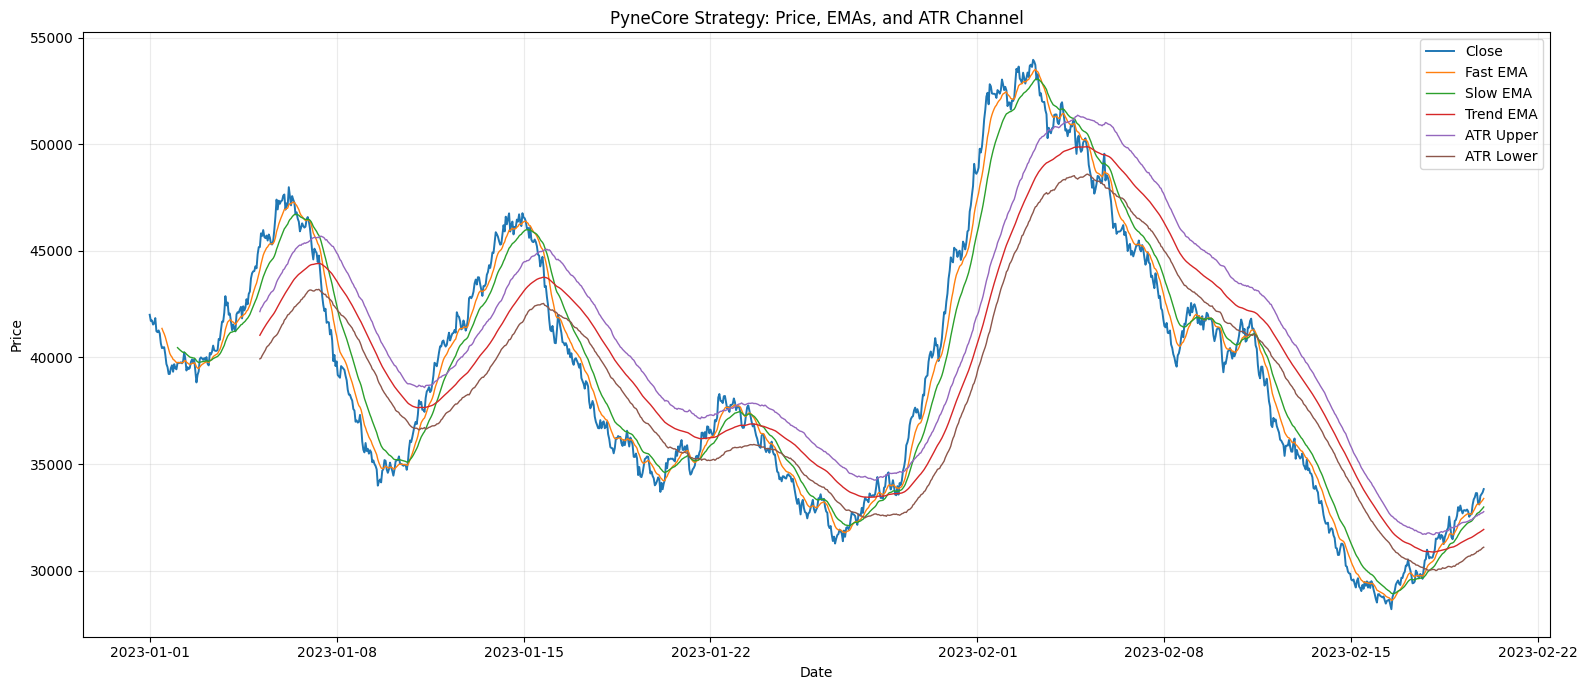

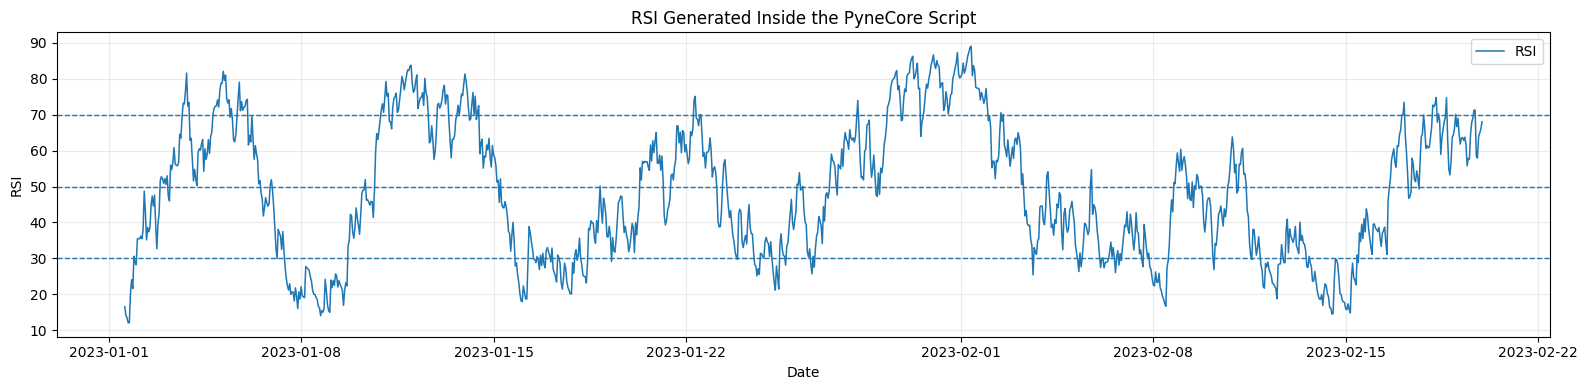

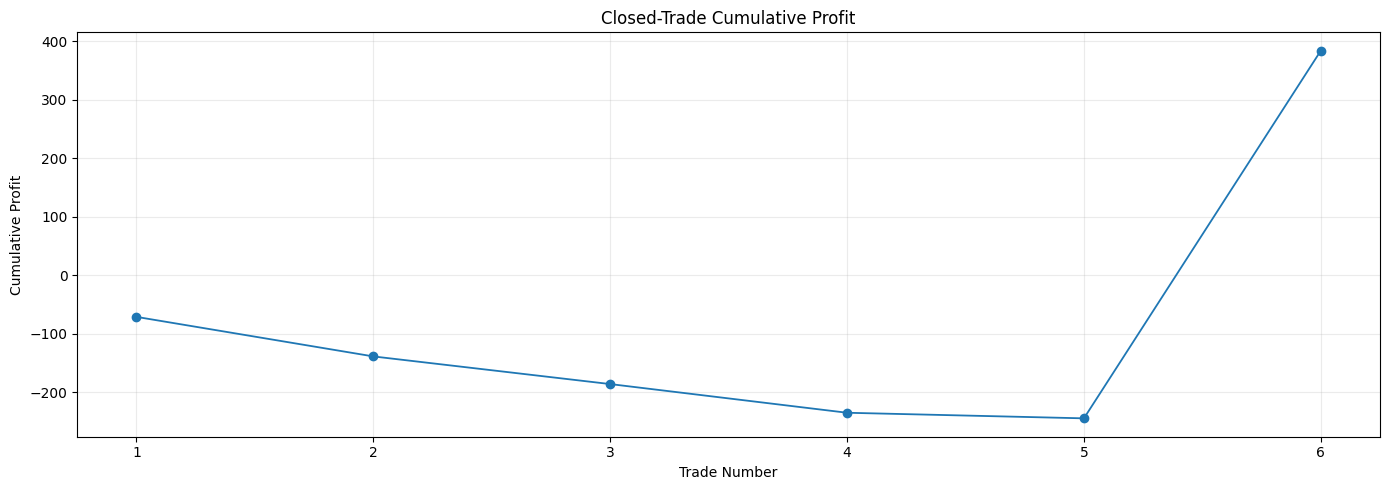

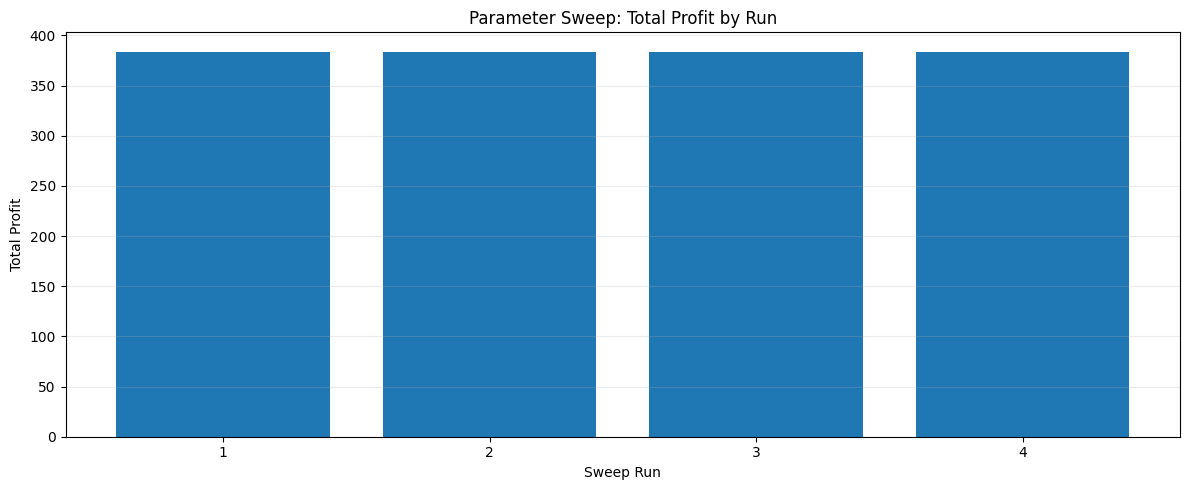


Running optional PyneCore CLI smoke test...

✓ Loading PyneCore...
✓ Running script... 2023-02-19 23:00 ━━━━━━━━━━━━━━━━━━━━━ 00:00.180 / 00:00.000

CLI run succeeded.
CLI plot: True
CLI stats: True
CLI trades: True

Tutorial completed.
{
  "root": "/content/pynecore_advanced_tutorial",
  "data_csv": "/content/pynecore_advanced_tutorial/workdir/data/BINANCE_BTCUSDT_60.csv",
  "data_ohlcv": "/content/pynecore_advanced_tutorial/workdir/data/BINANCE_BTCUSDT_60.ohlcv",
  "symbol_toml": "/content/pynecore_advanced_tutorial/workdir/data/BINANCE_BTCUSDT_60.toml",
  "strategy_script": "/content/pynecore_advanced_tutorial/workdir/scripts/advanced_ema_rsi_atr_strategy.py",
  "plot_csv": "/content/pynecore_advanced_tutorial/workdir/output/advanced_ema_rsi_atr_plot.csv",
  "strategy_stats_csv": "/content/pynecore_advanced_tutorial/workdir/output/advanced_ema_rsi_atr_stats.csv",
  "trade_csv": "/content/pynecore_advanced_tutorial/workdir/output/advanced_ema_rsi_atr_trades.csv",
  "analysis_dir": "

In [5]:
plot_ready = bars.copy()
plot_ready = plot_ready.dropna(subset=["close"])

plt.figure(figsize=(16, 7))
plt.plot(plot_ready["datetime"], plot_ready["close"], label="Close", linewidth=1.4)

for col in ["Fast EMA", "Slow EMA", "Trend EMA", "ATR Upper", "ATR Lower"]:
    if col in plot_ready.columns:
        plt.plot(plot_ready["datetime"], plot_ready[col], label=col, linewidth=1.0)

plt.title("PyneCore Strategy: Price, EMAs, and ATR Channel")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

if "RSI" in plot_ready.columns:
    plt.figure(figsize=(16, 4))
    plt.plot(plot_ready["datetime"], plot_ready["RSI"], label="RSI", linewidth=1.1)
    plt.axhline(70, linestyle="--", linewidth=1)
    plt.axhline(50, linestyle="--", linewidth=1)
    plt.axhline(30, linestyle="--", linewidth=1)
    plt.title("RSI Generated Inside the PyneCore Script")
    plt.xlabel("Date")
    plt.ylabel("RSI")
    plt.legend()
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

if len(trades_df):
    plt.figure(figsize=(14, 5))
    plt.plot(trades_df["trade_no"], trades_df["cum_profit"], marker="o", linewidth=1.3)
    plt.title("Closed-Trade Cumulative Profit")
    plt.xlabel("Trade Number")
    plt.ylabel("Cumulative Profit")
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(12, 5))
plt.bar(sweep_results["run"].astype(str), sweep_results["total_profit"])
plt.title("Parameter Sweep: Total Profit by Run")
plt.xlabel("Sweep Run")
plt.ylabel("Total Profit")
plt.grid(True, axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

print("\nRunning optional PyneCore CLI smoke test...")

cli_plot = OUTPUT_DIR / "cli_plot.csv"
cli_strat = OUTPUT_DIR / "cli_stats.csv"
cli_trade = OUTPUT_DIR / "cli_trades.csv"

for p in [cli_plot, cli_strat, cli_trade]:
    if p.exists():
        p.unlink()

cli_cmd = [
    "pyne", "run",
    strategy_path.name,
    csv_path.name,
    "--plot", str(cli_plot),
    "--strat", str(cli_strat),
    "--trade", str(cli_trade),
]

cli_result = subprocess.run(
    cli_cmd,
    cwd=ROOT,
    text=True,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
)

print(cli_result.stdout[-4000:])

if cli_result.returncode == 0:
    print("CLI run succeeded.")
    print("CLI plot:", cli_plot.exists())
    print("CLI stats:", cli_strat.exists())
    print("CLI trades:", cli_trade.exists())
else:
    print("CLI smoke test did not complete, but the programmatic ScriptRunner tutorial above already ran.")
    print("Return code:", cli_result.returncode)

bars.to_csv(ANALYSIS_DIR / "programmatic_plot_data.csv", index=False)
trades_df.to_csv(ANALYSIS_DIR / "programmatic_trades.csv", index=False)

manifest = {
    "root": str(ROOT),
    "data_csv": str(csv_path),
    "data_ohlcv": str(ohlcv_path),
    "symbol_toml": str(toml_path),
    "strategy_script": str(strategy_path),
    "plot_csv": str(plot_path),
    "strategy_stats_csv": str(strat_path),
    "trade_csv": str(trade_path),
    "analysis_dir": str(ANALYSIS_DIR),
    "closed_trades": int(len(trades_df)),
    "parameter_sweep_runs": int(len(sweep_results)),
}

(ANALYSIS_DIR / "manifest.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")

print("\nTutorial completed.")
print(json.dumps(manifest, indent=2))